#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Необходимо построить модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

План работы:

1. Загрузка данных и их ресемплирование по одному часу.
2. Анализ данных.
3. Обучение разных моделей с различными гиперпараметрами. Тестовую выборка - размером 10% от исходных данных.
4. Проверка данных на тестовой выборке
5. Выводы

Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders`.

## Подготовка данных

In [1]:
!pip install --upgrade scikit-learn -q
!pip install lightgbm -q
!pip install statsmodels -q


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose

import time


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Зададим переменные RANDOM_STATE и TEST_SIZE
RANDOM_STATE = 42
TEST_SIZE = 0.1

In [3]:
# загрузим данные
try:
    df = pd.read_csv('/datasets/taxi.csv',index_col=[0], parse_dates=[0])
except:
    df = pd.read_csv('taxi.csv',index_col=[0], parse_dates=[0])

In [4]:
#Сортировка по индексам
df.sort_index(inplace=True)
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


## Анализ данных

In [6]:
# Проверим пропуски
df.isna().sum()

num_orders    0
dtype: int64

In [7]:
# Статистика
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_orders,26496.0,14.070463,9.21133,0.0,8.0,13.0,19.0,119.0


<Axes: xlabel='datetime'>

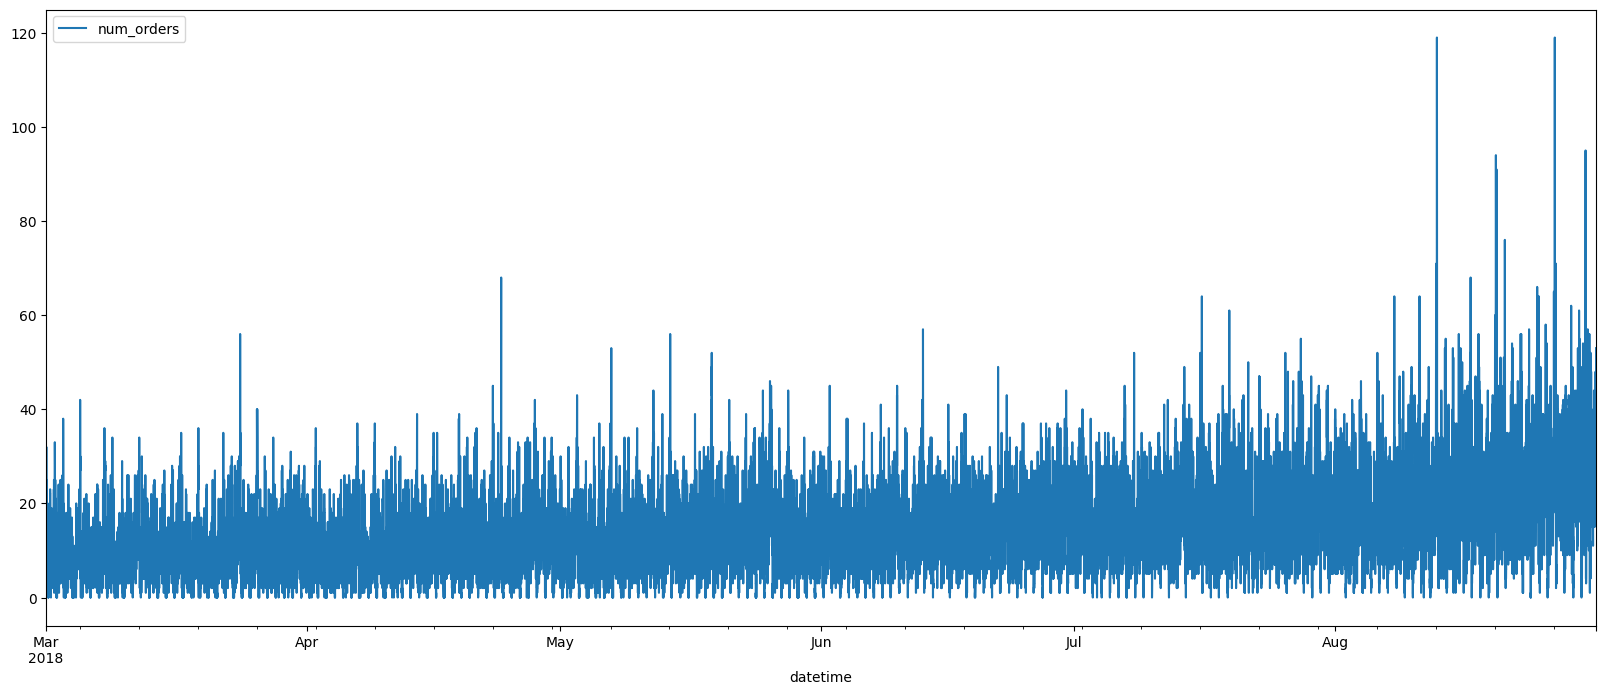

In [8]:
df.plot(figsize=(20,8))

In [9]:
# Ресэмплируем временной ряд интервалом в 1 час
df = df.resample('1H').sum()
df.head()

C:\Users\Тимур\AppData\Local\Temp\ipykernel_14024\2713625884.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample('1H').sum()


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


Text(0.5, 1.0, 'Количество заказов')

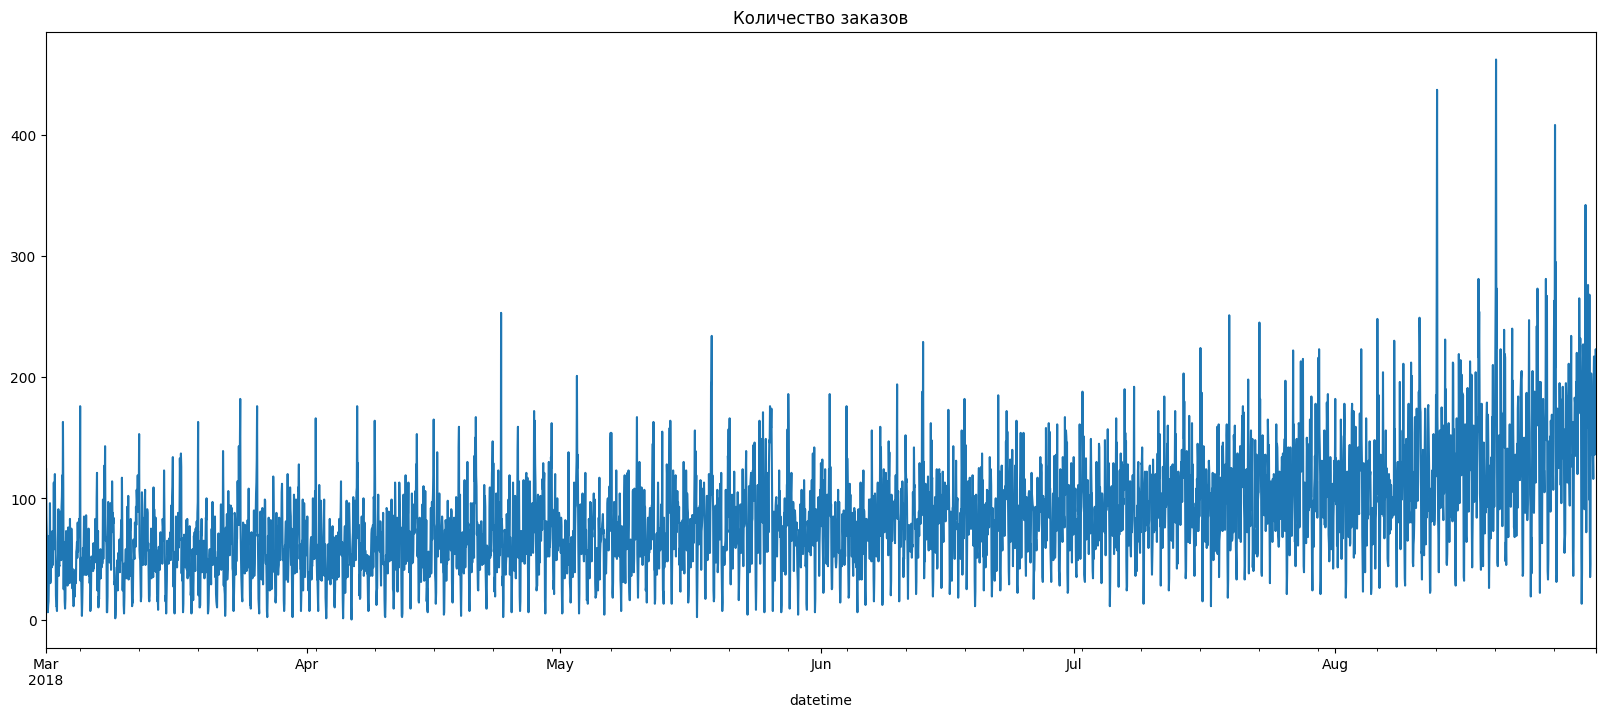

In [10]:
df['num_orders'].plot(figsize=(20,8))
plt.title('Количество заказов')

Text(0.5, 1.0, 'Количество заказов')

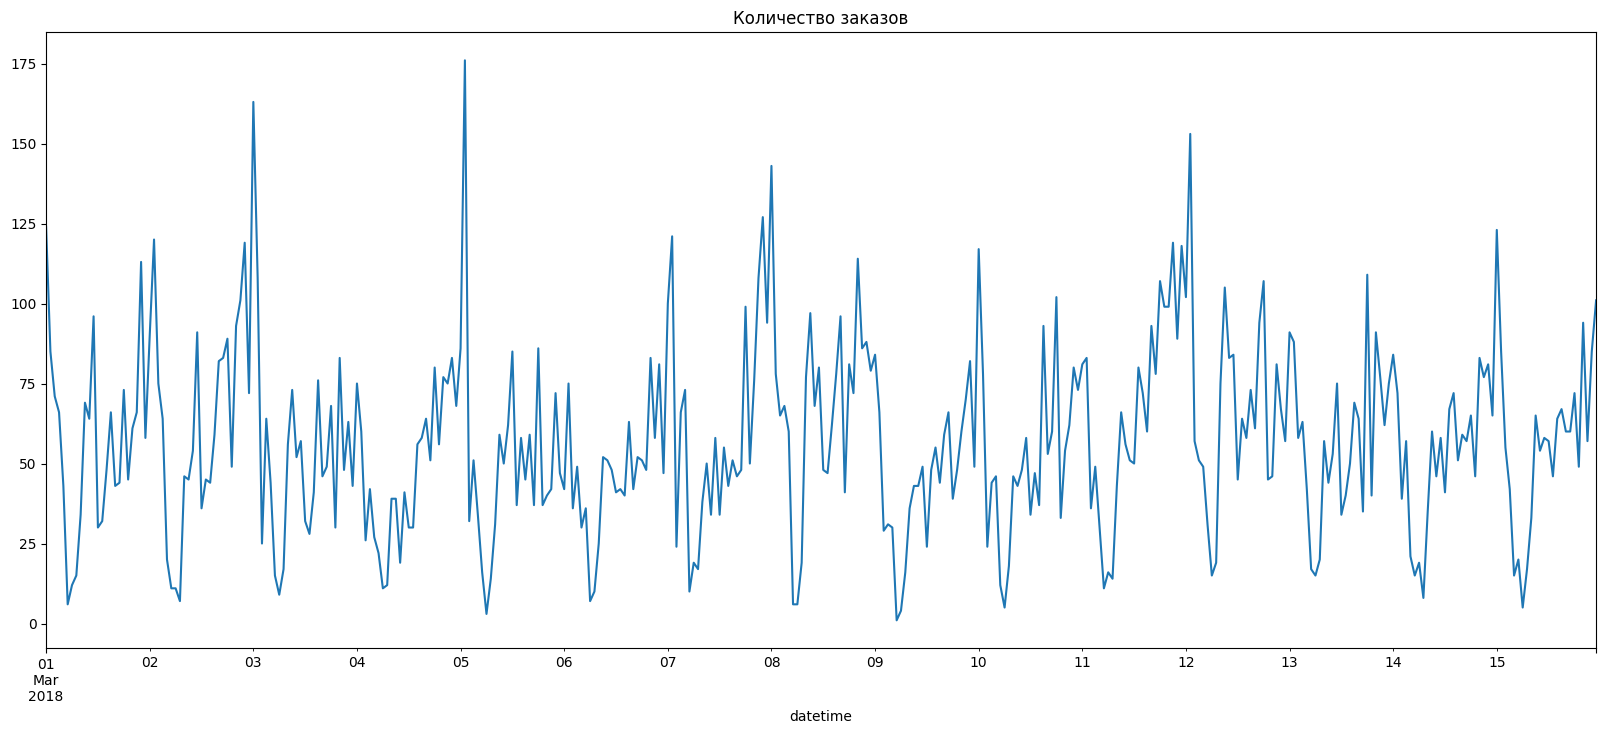

In [11]:
# Выведем график в увеличенном масштабе
df['num_orders']['2018-03-01':'2018-03-15'].plot(figsize=(20,8))
plt.title('Количество заказов')

In [12]:
# Разложим временной ряд на составляющие (тренд, сезонные колебания и шум)
decomposed = seasonal_decompose(df) 

Text(0.5, 1.0, 'Компонента "seasonal"')

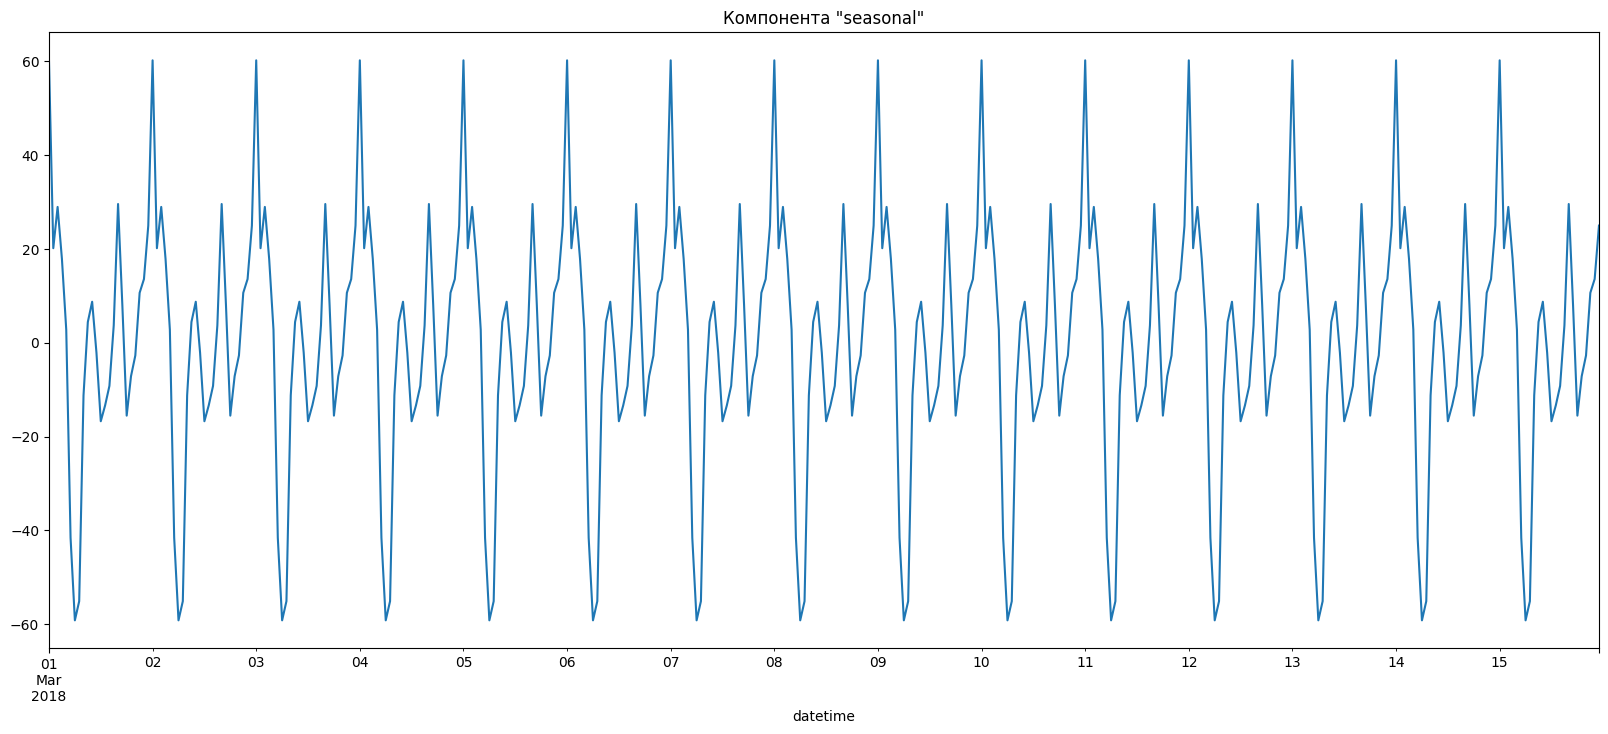

In [13]:
# Выведем сезонные колебания
decomposed.seasonal['2018-03-01':'2018-03-15'].plot(figsize=(20,8))
plt.title('Компонента "seasonal"')

Text(0.5, 1.0, 'Компонента "seasonal"')

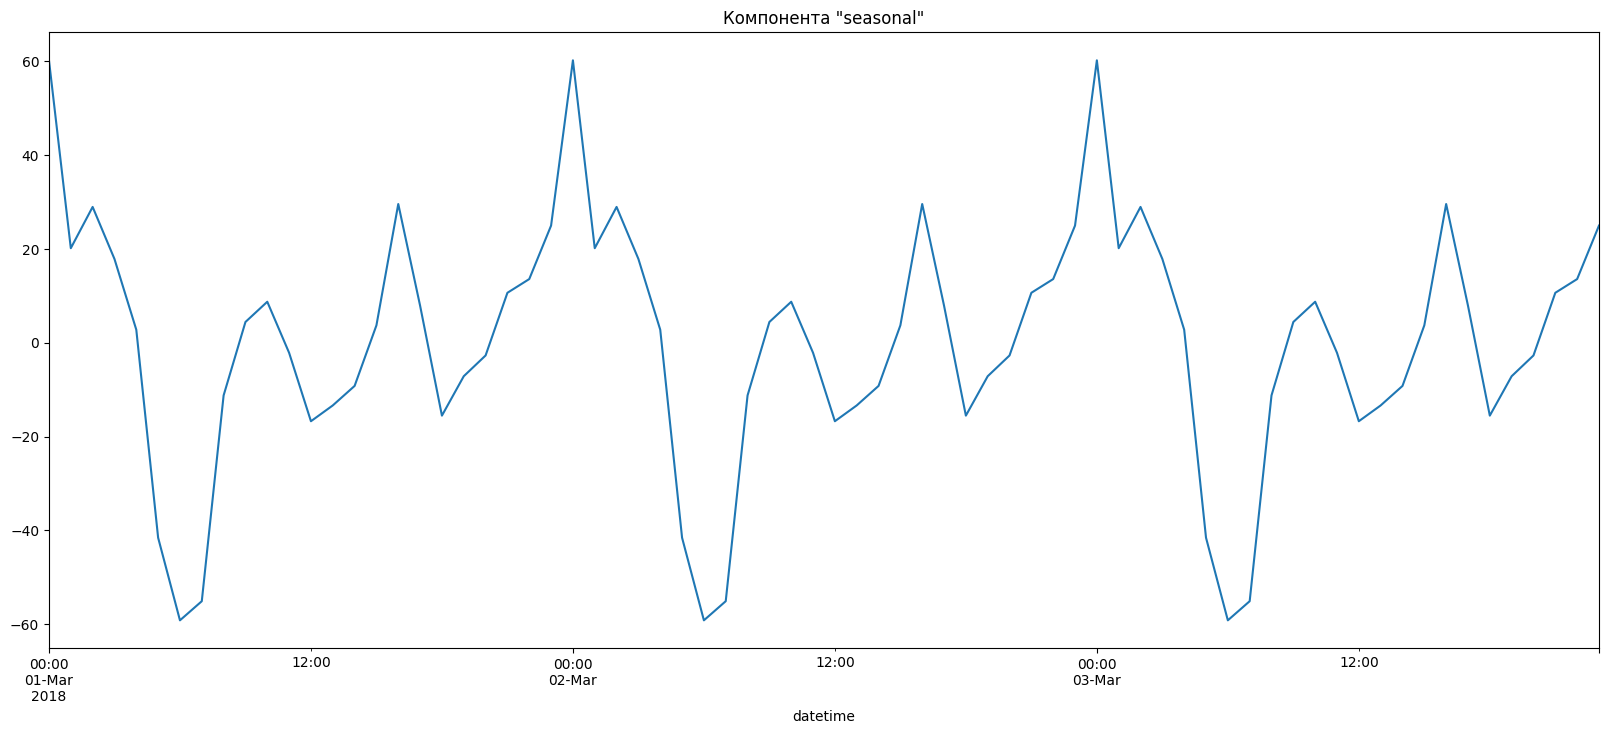

In [14]:
# Увеличим масштаб
decomposed.seasonal['2018-03-01':'2018-03-03'].plot(figsize=(20,8))
plt.title('Компонента "seasonal"')

Из графика видно, что наименьшее число заказов приходится на утренние часы, наибольшее - на поздний вечер.

Text(0.5, 1.0, 'Компонента "trend"')

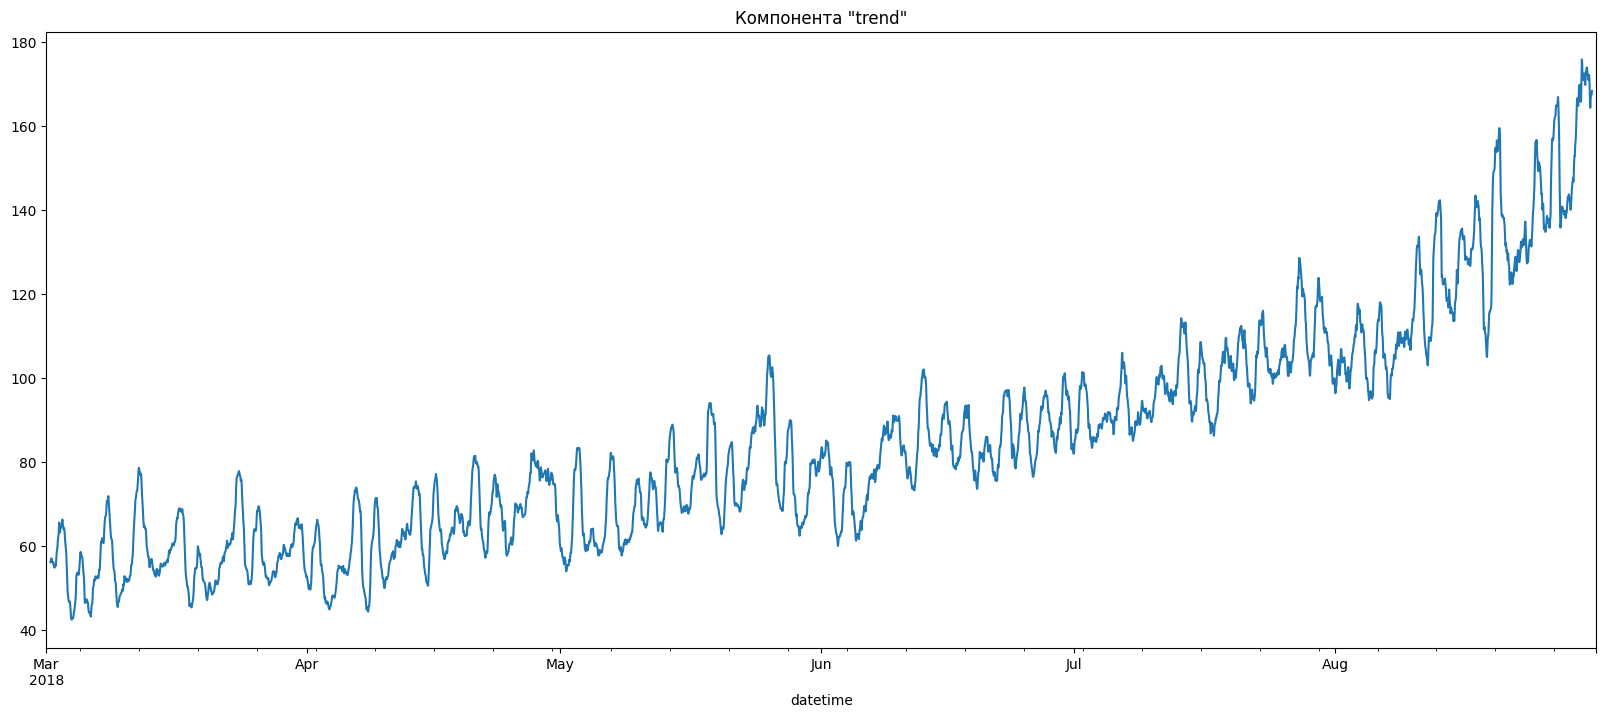

In [15]:
# Выведем тренд
decomposed.trend.plot(figsize=(20,8))
plt.title('Компонента "trend"')

Наблюдается возрастающий тренд, причем скорость роста резко увеличивается в августе, что, вероятно, связано, с сезоном отпусков.

Text(0.5, 1.0, 'Компонента "residual"')

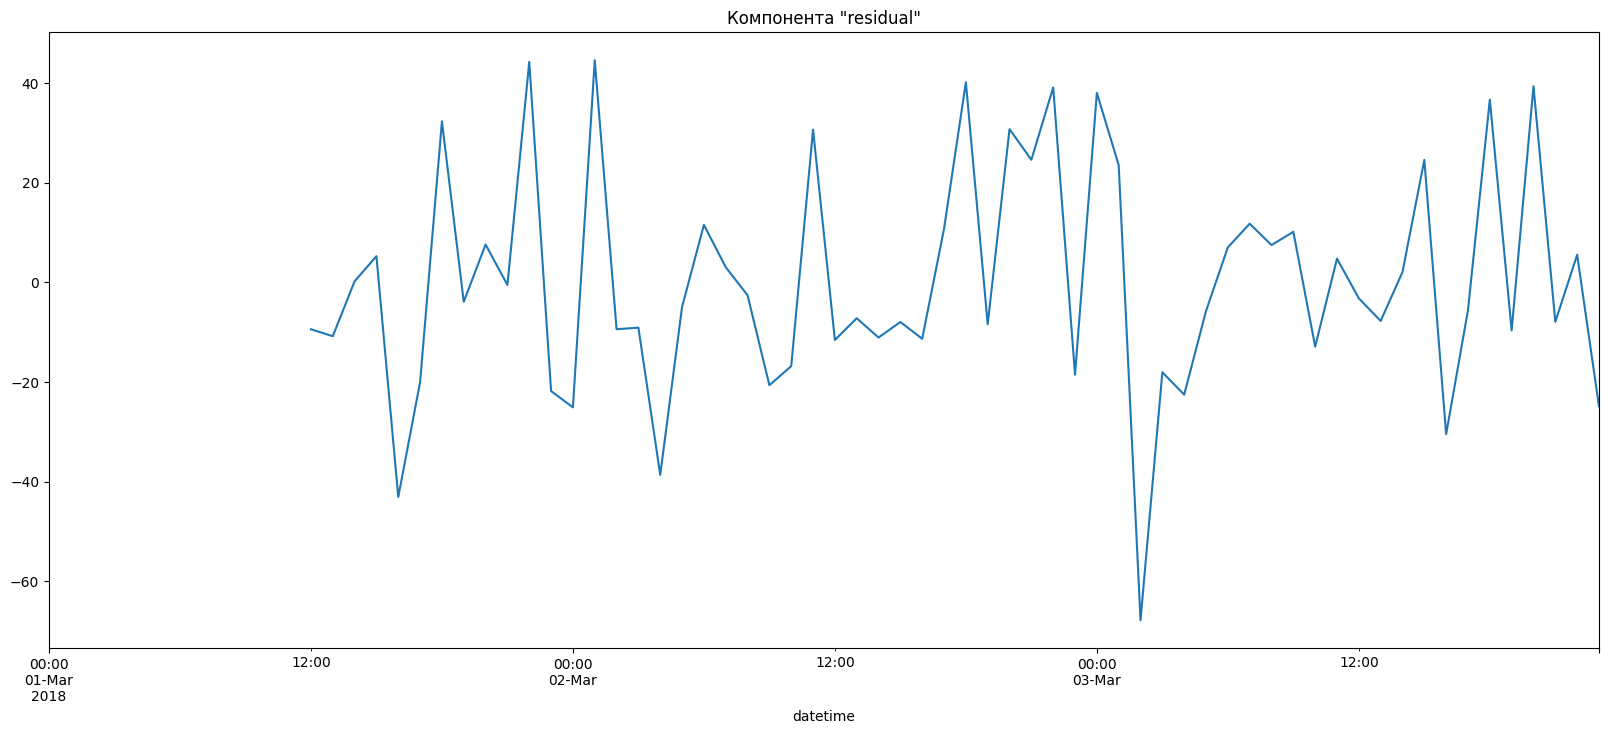

In [16]:
# Выведем остаточный шум
decomposed.resid['2018-03-01':'2018-03-03'].plot(figsize=(20,8))
plt.title('Компонента "residual"')

## Обучение моделей

In [17]:
# Функция для создания дополнительных признаков
def make_features(df, max_lag, rolling_mean_size):
    df['year'] = df.index.year
    df['month'] = df.index.month
    df['day'] = df.index.day
    df['dayofweek'] = df.index.dayofweek
    df['hour'] = df.index.hour
    
    for lag in range(1, max_lag + 1):
        df['lag_{}'.format(lag)] = df['num_orders'].shift(lag)

    df['rolling_mean'] = df['num_orders'].shift().rolling(rolling_mean_size).mean()

In [18]:
# Создадим признаки
make_features(df, 6, 3)

train, test = train_test_split(df, shuffle=False, test_size=TEST_SIZE)
train = train.dropna()

X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']


X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']

# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Пайплайн
pipe = Pipeline([
    ('models', LGBMRegressor(random_state=RANDOM_STATE))
])


In [19]:
# Гиперпараметры для моделей
param_grid = [
    {
        'models': [LGBMRegressor(random_state=RANDOM_STATE)],
        'models__num_leaves': [50, 100],
        'models__max_depth': [10, 20, 30],
        'models__n_estimators': [50, 100]
    },
    {
        'models': [RandomForestRegressor(random_state=RANDOM_STATE)],
        'models__n_estimators': [50, 100],
        'models__max_depth': [3, 5]
    },
    {
        'models': [CatBoostRegressor()],
        'models__iterations': [50, 100],
        'models__depth': [6, 10],
        'models__learning_rate': [0.05, 0.1]
    },
]

In [20]:
grid = GridSearchCV(
    pipe,
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    verbose=0
)

In [21]:
%%time
grid.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000647 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1465
[LightGBM] [Info] Number of data points in the train set: 3968, number of used features: 11
[LightGBM] [Info] Start training from score 78.309476
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
CPU times: total: 1.58 s
Wall time: 1min 45s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('models',
                                        LGBMRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'models': [LGBMRegressor(random_state=42)],
                          'models__max_depth': [10, 20, 30],
                          'models__n_estimators': [50, 100],
                          'models__num_leaves': [50, 100]},
                         {'models': [RandomForestRegressor(random_state=42)],
                          'models__max_depth': [3, 5],
                          'models__n_estimators': [50, 100]},
                         {'models': [<catboost.core.CatBoostRegressor object at 0x00000269D63B2D00>],
                          'models__depth': [6, 10],
                          'models__iterations': [50, 100],
                          'models__learning_rate': [0.05, 0.1]}],
             scoring='neg_root_mean_squared_error')

In [22]:
# Выведем модели, отсортированные по метрике на валидационной выборке
pd.set_option('display.max_colwidth', None)
cv_results = pd.DataFrame(grid.cv_results_)
cv_results[['params', 'mean_test_score', 'mean_fit_time', 'mean_score_time']].sort_values('mean_test_score', ascending=False).head(10)

,params,mean_test_score,mean_fit_time,mean_score_time
0,"{'models': LGBMRegressor(random_state=42), 'models__max_depth': 10, 'models__n_estimators': 50, 'models__num_leaves': 50}",-25.243964,3.213171,0.010894
8,"{'models': LGBMRegressor(random_state=42), 'models__max_depth': 30, 'models__n_estimators': 50, 'models__num_leaves': 50}",-25.290460,0.529310,0.012401
1,"{'models': LGBMRegressor(random_state=42), 'models__max_depth': 10, 'models__n_estimators': 50, 'models__num_leaves': 100}",-25.296764,0.496634,0.009001
4,"{'models': LGBMRegressor(random_state=42), 'models__max_depth': 20, 'models__n_estimators': 50, 'models__num_leaves': 50}",-25.317180,0.371459,0.008402
5,"{'models': LGBMRegressor(random_state=42), 'models__max_depth': 20, 'models__n_estimators': 50, 'models__num_leaves': 100}",-25.380151,0.479648,0.008202
9,"{'models': LGBMRegressor(random_state=42), 'models__max_depth': 30, 'models__n_estimators': 50, 'models__num_leaves': 100}",-25.385780,0.896455,0.010003
2,"{'models': LGBMRegressor(random_state=42), 'models__max_depth': 10, 'models__n_estimators': 100, 'models__num_leaves': 50}",-25.433524,0.706064,0.011201
3,"{'models': LGBMRegressor(random_state=42), 'models__max_depth': 10, 'models__n_estimators': 100, 'models__num_leaves': 100}",-25.528631,0.781117,0.012069
19,"{'models': <catboost.core.CatBoostRegressor object at 0x00000269D63B2D00>, 'models__depth': 6, 'models__iterations': 100, 'models__learning_rate': 0.1}",-25.583678,2.684026,0.012202
10,"{'models': LGBMRegressor(random_state=42), 'models__max_depth': 30, 'models__n_estimators': 100, 'models__num_leaves': 50}",-25.629835,1.808550,0.011401


In [23]:
print('Лучшая модель и её параметры:\n\n', grid.best_estimator_)
print ('Метрика лучшей модели по кроссвалидационной выборке:', -grid.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('models',
                 LGBMRegressor(max_depth=10, n_estimators=50, num_leaves=50,
                               random_state=42))])
Метрика лучшей модели по кроссвалидационной выборке: 25.243963708735663


## Тестирование модели

In [24]:
# Получим предсказание на тестовой выборке
y_test_pred = grid.predict(X_test)

In [25]:
print("RMSE на тестовой выборке:", mean_squared_error(y_test, y_test_pred)**0.5)

RMSE на тестовой выборке: 43.87519178362933


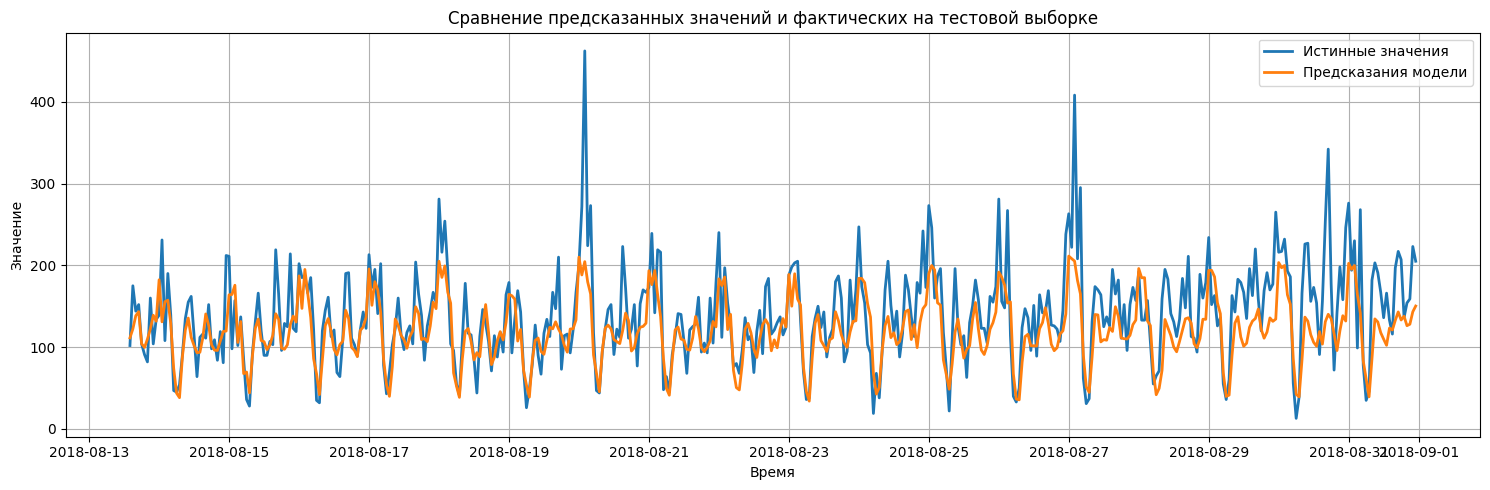

In [26]:
# Наложим графики истинных и предсказанных значений
plt.figure(figsize=(15, 5))

plt.plot(y_test.index, y_test, label='Истинные значения', linewidth=2)
plt.plot(y_test.index, y_test_pred, label='Предсказания модели', linewidth=2)

plt.xlabel('Время')
plt.ylabel('Значение')
plt.title('Сравнение предсказанных значений и фактических на тестовой выборке')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

По графику видим, что самые большие расхождения между предсказанными и фактическими значениями на тестовой выборке возникают на вылетах, а также прогноз ухудшается, начиная с 2018-08-28. Значение RMSE на тестовой выборке превышает значение на тренировочной выборке, однако соответствует требованиям задачи.

## Выводы

Было выполнено: 
- загрузка входного датасета и его ресэмплирование с интервалом 1 час  
- анализ временного ряда, выделены и проанализированы компоненты seasonal, trend и residual  
- перед обучением моделей созданы дополнительные признаки
- выполнено тестирование моделей LGBMRegressor, RandomForestRegressor, CatBoostRegressor на кроссвалидационной выборке
- получена модель LGBMRegressor(models__max_depth=10, n_estimators = 50, num_leaves = 50) с RMSE=43.8 на тестовой выборке